# HMM-Diffusion-EW

Regime-conditional synthetic financial time series with **equal-weight** true regime labels.

Each of the ten assets is z-scored, then averaged with equal weight. Vol_Regime is run on that series over the full 10-asset overlap, **2001-01-01 to 2022-08-31**. The HMM emission is the same equal-weight series. The HMM is trained on **2001-01-01 to 2014-01-03**. **2014-01-06 to 2022-08-31** is held out as the test set. There is no validation slice.

Diffusion specialists generate 10-asset windows, labeled by the EW regimes, and are trained on the full 2001–2022 overlap. The HMM is still trained only on 2001–2014.

Run the EW scripts before this notebook:

```
python scripts/01_label_regimes_ew.py
python scripts/02_build_diffusion_dataset_ew.py
python scripts/03_train_specialists_ew.py
python scripts/04_generate_pools_ew.py
```

Without stages 3 and 4 the notebook uses placeholder pools resampled from real EW returns. This notebook does not load `configs/default.yaml` and does not touch the A001 artifacts.


In [1]:
import sys
import warnings
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

REPO_ROOT = Path.cwd()
sys.path.insert(0, str(REPO_ROOT / "src"))

from hmmdiff.config import bootstrap_imports, config_path, load_config

cfg = load_config("configs/ew.yaml")
bootstrap_imports()

from hmmdiff import ew, models, plots, pools, regimes, stitch

warnings.filterwarnings("ignore")
pd.set_option("display.float_format", lambda v: f"{v:,.4f}")

N_REGIMES = cfg["regimes"]["n_regimes"]
TOP_K = cfg["hmm"]["top_k"]
REFERENCE = cfg["reference"]

print(f"{N_REGIMES} regimes, seq_len {cfg['diffusion']['seq_len']}")
print(f"config {Path('configs/ew.yaml')}")


5 regimes, seq_len 128
config configs/ew.yaml


## Data preparation

Ten-asset log returns start when every name has a price (A014 binds the start at 2001-01-01). Each column is standardized, the equal-weight average is z-scored, and dates inherit the A001 train/test cutoff: train through 2014-01-03, test from 2014-01-06. The HMM uses the full train slice; there is no inner train/validation split.


returns        5653  2001-01-01 to 2022-08-31
train / test   3395 / 2258
train end    2014-01-03    test start 2014-01-06


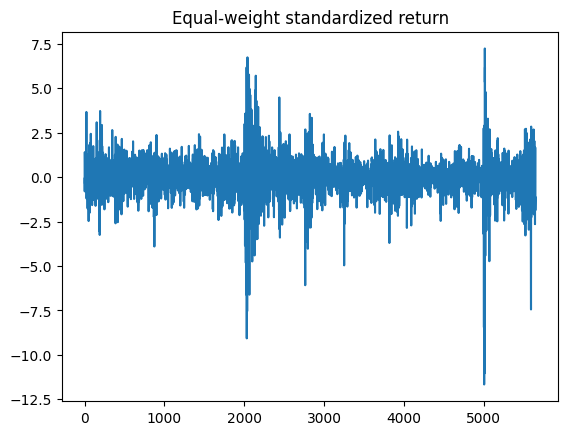

In [2]:
returns = ew.load_ew_returns(cfg)
counts = ew.split_counts(returns)
train_series, test_series = ew.split_series(returns)

print(f"returns      {counts['n_returns']:>6}  {counts['start_date']} to {counts['end_date']}")
print(f"train / test {counts['n_train']:>6} / {counts['n_test']}")
print(f"train end    {counts['train_end_date']}    test start {counts['test_start_date']}")

assert counts["n_returns"] == REFERENCE["n_returns"]
assert counts["n_train"] == REFERENCE["n_train"]
assert counts["n_test"] == REFERENCE["n_test"]
assert counts["start_date"] == REFERENCE["start_date"]
assert counts["train_end_date"] == REFERENCE["train_end_date"]
assert counts["test_start_date"] == REFERENCE["test_start_date"]

plots.plot_prices(returns["z_return"].to_numpy(dtype=float), title="Equal-weight standardized return")


## Volatility regimes

Labels are loaded from the cache written by `scripts/01_label_regimes_ew.py`. Clustering uses the **full** 2001–2022 equal-weight series. Labels are reordered so regime index increases with variance. Plots below show the full labeled series; the HMM is fit only on the train dates.


labels 5653 days  train 3395  test 2258


,n_days,mean,variance
regime,,,
0,1160,0.0088,0.2202
1,2600,0.0475,0.4735
2,1150,-0.0293,0.8459
3,443,-0.1449,1.9683
4,300,-0.1200,7.6668


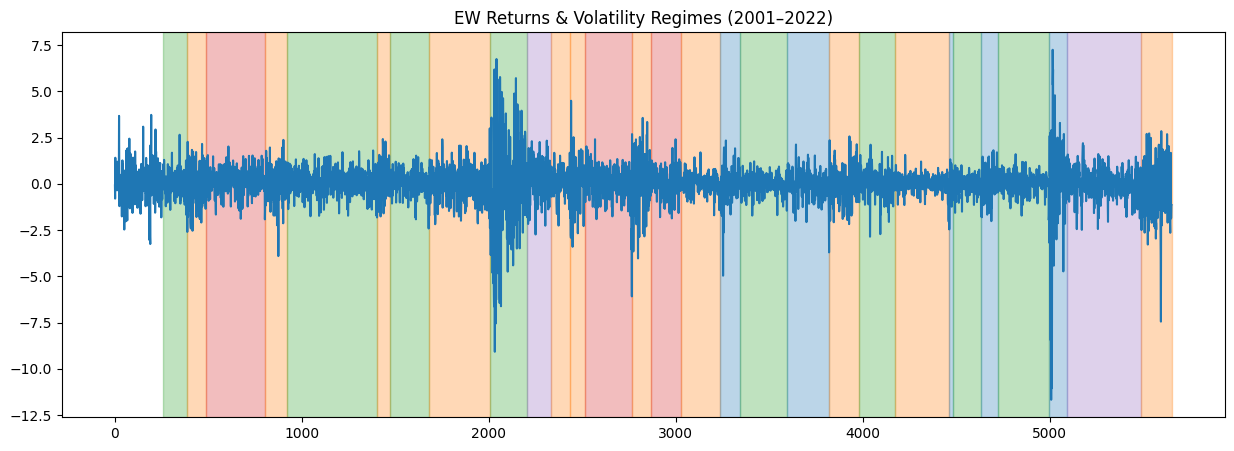

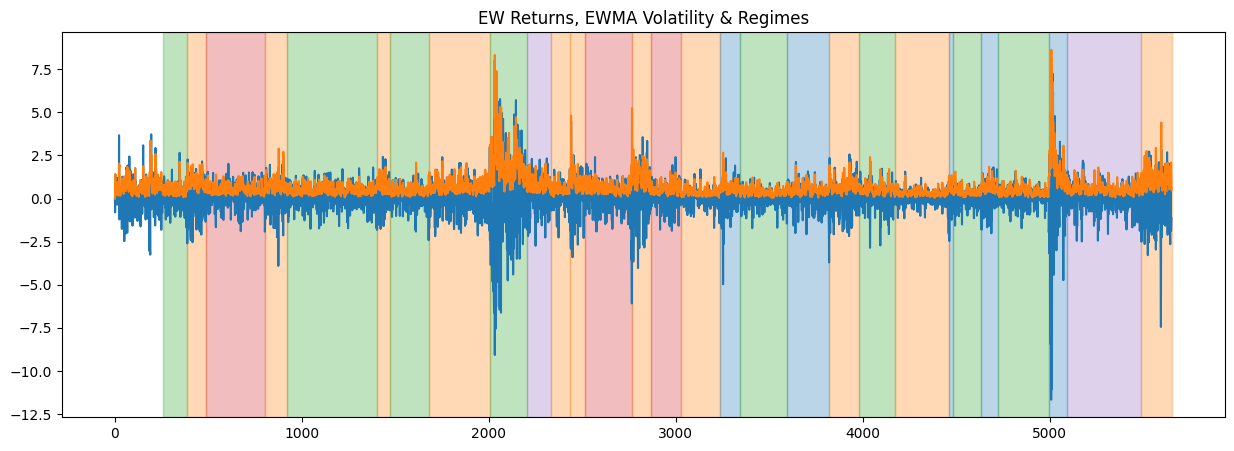

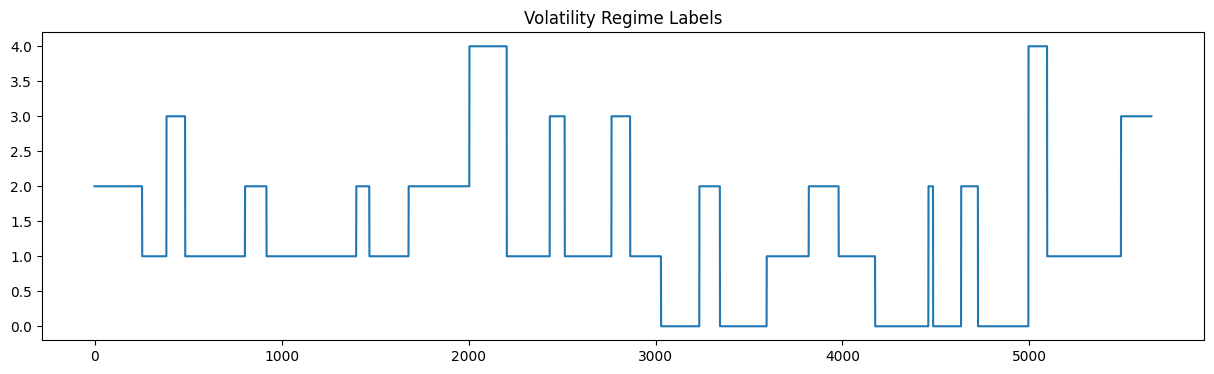

In [3]:
labels = regimes.load_labels(config_path(cfg, "regime_labels"))
regime_labels = labels.labels.astype(int)
train_labels, test_labels = ew.split_labels(returns, regime_labels)
segment_colors = labels.segment_colors()

print(f"labels {len(regime_labels)} days  train {len(train_labels)}  test {len(test_labels)}")
display(plots.regime_moments(returns["z_return"].to_numpy(dtype=float), regime_labels, N_REGIMES))

plots.plot_regime_spans(
    returns["z_return"].to_numpy(dtype=float),
    labels.changepoints,
    segment_colors,
    title="EW Returns & Volatility Regimes (2001–2022)",
)
plots.plot_regime_spans(
    returns["z_return"].to_numpy(dtype=float),
    labels.changepoints,
    segment_colors,
    overlay=regimes.ewm_volatility(returns["z_return"].to_numpy(dtype=float), cfg["regimes"]["ewm_com"]),
    title="EW Returns, EWMA Volatility & Regimes",
)
plots.plot_regime_labels(regime_labels)


## Model frames and transition structure

`train_data` is 2001–2014 and `test_data` is 2014–2022. Each frame holds the EW regime label, the EW emission, and the lagged emission for the Markov switching variant. The empirical transition matrix below is estimated on the train labels, which is the path the HMM is trained against.


In [4]:
train_data, test_data = ew.build_train_test_frames(returns, regime_labels)

coverage = pd.DataFrame(
    {
        "train": np.bincount(train_data.regime.values, minlength=N_REGIMES),
        "test": np.bincount(test_data.regime.values, minlength=N_REGIMES),
    },
    index=pd.Index(range(N_REGIMES), name="regime"),
)
display(coverage)

missing_train = coverage.index[coverage["train"] == 0].tolist()
assert not missing_train, (
    f"Regimes {missing_train} are absent from the training slice, so their emission parameters "
    "would come from the prior. Re-run scripts/01_label_regimes_ew.py with a different "
    "regimes.changepoint_penalty."
)
missing_test = coverage.index[coverage["test"] == 0].tolist()
if missing_test:
    print(
        f"Note: regimes {missing_test} do not occur in the test slice, so test accuracy "
        "is measured over the remaining regimes only."
    )


,train,test
regime,,
0,255,905
1,1785,815
2,875,275
3,280,163
4,200,100


In [5]:
empirical_transmat = regimes.empirical_transition_matrix(train_labels, N_REGIMES)
outbound_transmat = regimes.outbound_transition_matrix(empirical_transmat, N_REGIMES)

index = pd.Index(range(N_REGIMES), name="from")
columns = pd.Index(range(N_REGIMES), name="to")

print("Empirical transition matrix (train)")
display(pd.DataFrame(empirical_transmat, index=index, columns=columns))

print("Outbound transition matrix (diagonal removed, rows renormalized)")
display(pd.DataFrame(outbound_transmat, index=index, columns=columns))

print("Average consecutive days per visit (full 2001–2022 labels)")
display(pd.Series(regimes.average_regime_length(regime_labels)).sort_index())


Empirical transition matrix (train)


to,0,1,2,3,4
from,,,,,
0,0.9961,0.0000,0.0039,0.0000,0.0000
1,0.0006,0.9961,0.0017,0.0017,0.0000
2,0.0011,0.0034,0.9943,0.0000,0.0011
3,0.0000,0.0107,0.0000,0.9893,0.0000
4,0.0000,0.0050,0.0000,0.0000,0.9950


Outbound transition matrix (diagonal removed, rows renormalized)


to,0,1,2,3,4
from,,,,,
0,0.0000,0.0000,1.0000,0.0000,0.0000
1,0.1429,0.0000,0.4286,0.4286,0.0000
2,0.2000,0.6000,0.0000,0.0000,0.2000
3,0.0000,1.0000,0.0000,0.0000,0.0000
4,0.0000,1.0000,0.0000,0.0000,0.0000


Average consecutive days per visit (full 2001–2022 labels)


0   232.0000
1   260.0000
2   143.7500
3   110.7500
4   150.0000
dtype: float64

## Diffusion pools

One pool of synthetic 128-day, 10-asset windows per regime. For stitching, each window is mapped to EW emission units: z-score each asset with the overlap moments, average, then z-score the equal-weight series. If specialists are not trained yet, placeholder pools are resampled from real per-regime EW train returns.


In [6]:
pools_root = config_path(cfg, "pools")
USING_PLACEHOLDER = not pools.pools_available(pools_root, N_REGIMES)
GENERATED_TITLE = (
    "PLACEHOLDER: Resampled Real EW Returns (not diffusion)"
    if USING_PLACEHOLDER
    else "HMM Diffusion Generated EW Returns"
)

if USING_PLACEHOLDER:
    print(
        "WARNING: no trained specialist pools found under "
        f"{pools_root.relative_to(REPO_ROOT)}.\n"
        "Falling back to placeholder pools resampled from the real per-regime EW returns.\n"
        "Run scripts/03_train_specialists_ew.py and scripts/04_generate_pools_ew.py for real results."
    )
    generated_images = pools.placeholder_pools(
        train_series, train_labels, N_REGIMES, size=len(train_series), seed=0
    )
else:
    regime_stats = pools.regime_emission_stats(
        train_data.emission.values, train_data.regime.values, N_REGIMES
    )
    generated_images = pools.load_generated_images_ew(
        pools_root,
        N_REGIMES,
        scale=labels.metadata,
        calibrate_regimes=regime_stats,
    )
    print(
        "Pool EW rescaled: 10-asset z-score, equal-weight, then EW z-score "
        f"(ew_mean={labels.metadata['ew_mean']:.6e}, ew_sd={labels.metadata['ew_std']:.6e}) "
        "+ per-regime calibration"
    )
    for k in range(N_REGIMES):
        meta = pools.load_pool_meta(pools_root, k)
        print(f"regime {k}: {meta.get('n_pool')} windows from {Path(meta.get('checkpoint_dir', '')).name}")

pool_summary = pd.DataFrame(
    {
        "pool_length": [generated_images[str(k)].size for k in range(N_REGIMES)],
        "pool_mean": [generated_images[str(k)].mean() for k in range(N_REGIMES)],
        "pool_var": [generated_images[str(k)].var() for k in range(N_REGIMES)],
        "real_mean": [train_series[train_labels == k].mean() for k in range(N_REGIMES)],
        "real_var": [train_series[train_labels == k].var() for k in range(N_REGIMES)],
    },
    index=pd.Index(range(N_REGIMES), name="regime"),
)
display(pool_summary)

candidate_paths = [train_data.regime.values, test_data.regime.values]
problems, _ = pools.check_pools(
    generated_images, candidate_paths, train_series, train_labels, N_REGIMES
)
for problem in problems:
    print(f"POOL CHECK: {problem}")
if not problems:
    print("Pool checks passed: finite, sufficient for every regime path, variance ordering matches.")


Pool EW rescaled: 10-asset z-score, equal-weight, then EW z-score (ew_mean=2.513861e-18, ew_sd=6.132974e-01) + per-regime calibration
regime 0: 128 windows from checkpoints\ew\diffusion_denoised_x_UniTST_MP_ALL_RegimeWindows_1.0-KL2_N+1.0-Corr+1.0-FFT_sl128_ds0_cmTrue_ceTrue_ipTrue_RoPE_specialist_regime_0
regime 1: 128 windows from checkpoints\ew\diffusion_denoised_x_UniTST_MP_ALL_RegimeWindows_1.0-KL2_N+1.0-Corr+1.0-FFT_sl128_ds0_cmTrue_ceTrue_ipTrue_RoPE_specialist_regime_1
regime 2: 128 windows from checkpoints\ew\diffusion_denoised_x_UniTST_MP_ALL_RegimeWindows_1.0-KL2_N+1.0-Corr+1.0-FFT_sl128_ds0_cmTrue_ceTrue_ipTrue_RoPE_specialist_regime_2
regime 3: 128 windows from checkpoints\ew\diffusion_denoised_x_UniTST_MP_ALL_RegimeWindows_1.0-KL2_N+1.0-Corr+1.0-FFT_sl128_ds0_cmTrue_ceTrue_ipTrue_RoPE_specialist_regime_3
regime 4: 128 windows from checkpoints\ew\diffusion_denoised_x_UniTST_MP_ALL_RegimeWindows_1.0-KL2_N+1.0-Corr+1.0-FFT_sl128_ds0_cmTrue_ceTrue_ipTrue_RoPE_specialist_regim

,pool_length,pool_mean,pool_var,real_mean,real_var
regime,,,,,
0,16384,0.0106,0.2274,0.0106,0.2274
1,16384,0.0732,0.4712,0.0732,0.4712
2,16384,-0.0288,0.8477,-0.0288,0.8477
3,16384,-0.0564,1.8521,-0.0564,1.8521
4,16384,-0.1225,7.2344,-0.1225,7.2344


Pool checks passed: finite, sufficient for every regime path, variance ordering matches.


## HMM variants

Four ways of estimating a transition matrix and per-regime Gaussian emission parameters. Supervised HMM treats regimes and emissions as observed and is fit with NUTS. Markov switching regresses the emission mean on the previous emission. Semi-supervised keeps labels on the first half of training and treats the second half as unlabeled. Neural HMM uses a small network for emission parameters fit by SVI.

All four are evaluated the same way: forward-backward smoothing, comparison to true EW labels, stitching along the estimated path, and per-regime moment tables. Accuracy is reported on train (2001–2014) and test (2014–2022). Top-2 accuracy is reported alongside top-1 because adjacent volatility regimes overlap heavily.


In [7]:
init_dist = models.initial_distribution(train_data, N_REGIMES)


def evaluate_variant(key, fit):
    """Fit diagnostics, state estimation, stitching, and plots for one HMM variant."""
    print("=" * 78)
    print(fit.name)
    print("=" * 78)

    print("Posterior transition matrix")
    display(pd.DataFrame(fit.transmat.round(3), index=index, columns=columns))
    print("Emission parameters")
    display(fit.summary())

    train_probs, train_est = models.estimate_states(
        fit, train_data.emission.values, init_dist, N_REGIMES
    )
    test_probs, test_est = models.estimate_states(
        fit, test_data.emission.values, init_dist, N_REGIMES
    )
    train_acc = models.accuracy_report(
        train_data.regime.values, train_est, train_probs, N_REGIMES, TOP_K
    )
    test_acc = models.accuracy_report(
        test_data.regime.values, test_est, test_probs, N_REGIMES, TOP_K
    )

    print(
        f"Train accuracy {train_acc['accuracy']:>7.2%}   "
        f"top-{TOP_K} {train_acc[f'top_{TOP_K}_accuracy']:>7.2%}"
    )
    print(
        f"Test  accuracy {test_acc['accuracy']:>7.2%}   "
        f"top-{TOP_K} {test_acc[f'top_{TOP_K}_accuracy']:>7.2%}"
    )

    plots.plot_estimates(train_est, train_data.regime.values, f"{fit.name}: Train")
    plots.plot_estimates(test_est, test_data.regime.values, f"{fit.name}: Test")

    oracle = stitch.stitch(generated_images, train_data.regime.values)
    estimated, test_estimated = plots.plot_paper_train_test(
        train_data.emission.values,
        train_data.regime.values,
        train_est,
        test_data.emission.values,
        test_data.regime.values,
        test_est,
        generated_images,
        generated_title=GENERATED_TITLE,
    )

    table = stitch.backtest_table(
        train_data.emission.values,
        train_data.regime.values,
        estimated,
        train_est,
        N_REGIMES,
    )
    test_table = stitch.backtest_table(
        test_data.emission.values,
        test_data.regime.values,
        test_estimated,
        test_est,
        N_REGIMES,
    )
    print("Train backtest")
    display(table)
    print("Test backtest")
    display(test_table)

    return {
        "name": fit.name,
        "fit": fit,
        "train_accuracy": train_acc["accuracy"],
        "train_top_k": train_acc[f"top_{TOP_K}_accuracy"],
        "test_accuracy": test_acc["accuracy"],
        "test_top_k": test_acc[f"top_{TOP_K}_accuracy"],
        "oracle": oracle,
        "estimated": estimated,
        "test_estimated": test_estimated,
        "backtest": table,
        "test_backtest": test_table,
    }


results = {}


sample: 100%|██████████| 300/300 [00:05<00:00, 50.45it/s, 31 steps of size 1.83e-01. acc. prob=0.91] 

Supervised HMM
Posterior transition matrix


to,0,1,2,3,4
from,,,,,
0,0.9900,0.0010,0.0080,0.0010,0.0010
1,0.0010,0.9960,0.0020,0.0020,0.0000
2,0.0010,0.0040,0.9930,0.0000,0.0010
3,0.0010,0.0110,0.0010,0.9870,0.0010
4,0.0010,0.0060,0.0010,0.0010,0.9910


Emission parameters


,mean,sigma
regime,,
0,0.0143,0.4800
1,0.0747,0.6868
2,-0.0300,0.9242
3,-0.0752,1.3825
4,-0.1354,2.7122


100%|██████████| 3395/3395 [00:00<00:00, 103635.04it/s]
3395it [00:00, 102701.47it/s]
100%|██████████| 2258/2258 [00:00<00:00, 101651.18it/s]
2258it [00:00, 101406.28it/s]


Train accuracy  73.58%   top-2  90.31%
Test  accuracy  75.11%   top-2  94.29%


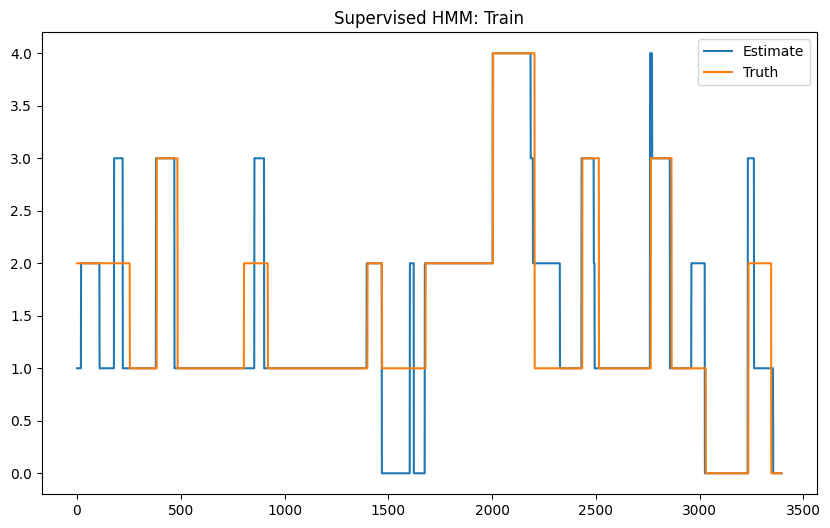

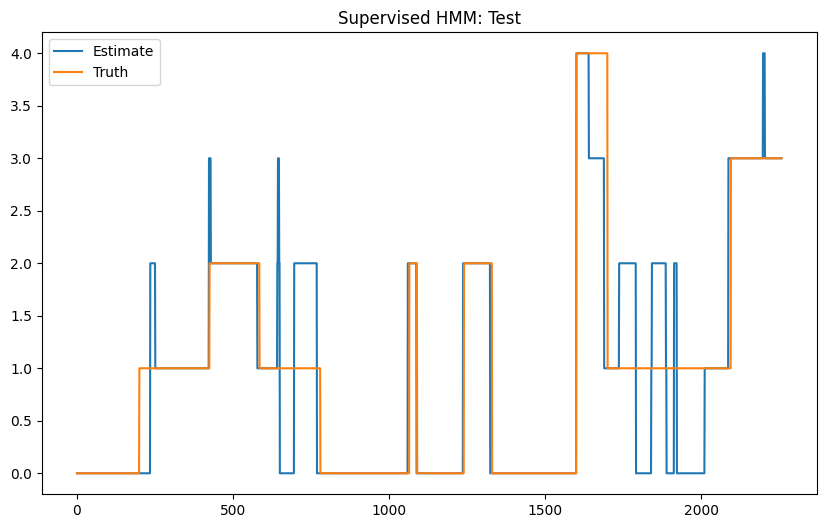

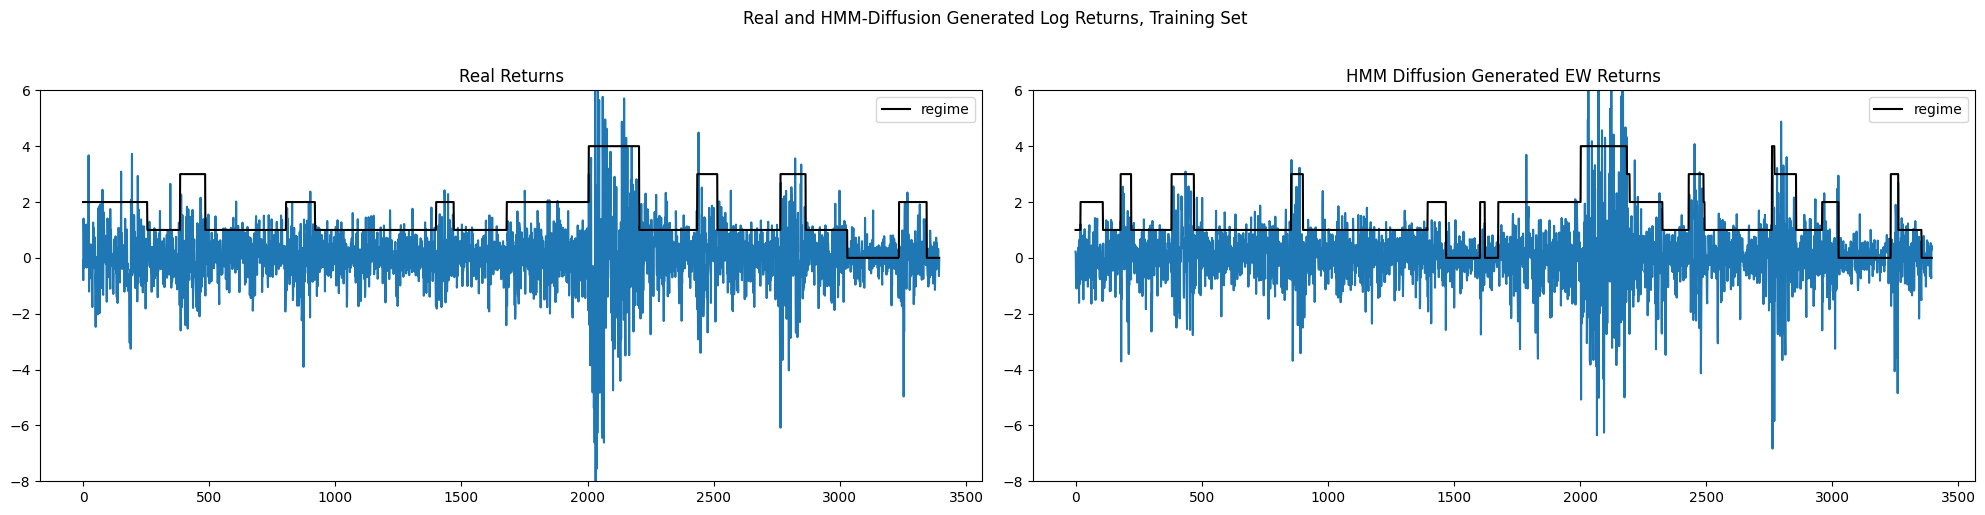

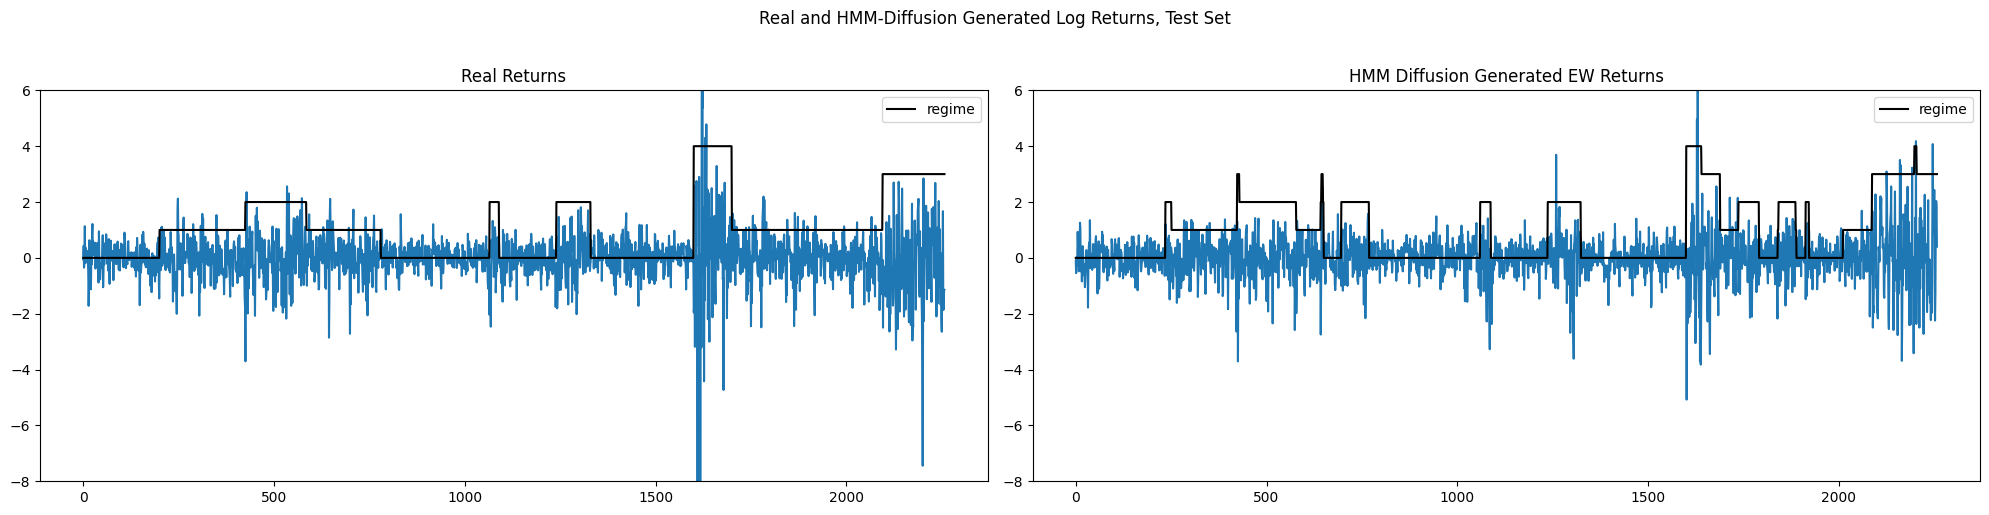

Train backtest


,n,real_mean,gen_mean,real_var,gen_var
regime,,,,,
0,255,0.0106,-0.0085,0.2283,0.2034
1,1785,0.0732,0.0367,0.4714,0.5449
2,875,-0.0288,-0.0362,0.8487,0.8628
3,280,-0.0564,0.0179,1.8587,2.0749
4,200,-0.1225,0.1041,7.2708,6.0106


Test backtest


,n,real_mean,gen_mean,real_var,gen_var
regime,,,,,
0,905,0.0083,0.0035,0.2184,0.2290
1,815,-0.0087,0.0042,0.4747,0.4369
2,275,-0.0308,-0.0899,0.8433,0.8119
3,163,-0.2969,0.0772,2.1447,2.1483
4,100,-0.1150,-0.1812,8.6179,2.5609


In [8]:
results["supervised"] = evaluate_variant(
    "supervised", models.fit_supervised_hmm(train_data, N_REGIMES, cfg)
)


sample: 100%|██████████| 300/300 [00:05<00:00, 52.27it/s, 15 steps of size 1.69e-01. acc. prob=0.79] 

Markov Switching Model
Posterior transition matrix


to,0,1,2,3,4
from,,,,,
0,0.9890,0.0010,0.0090,0.0010,0.0010
1,0.0010,0.9960,0.0020,0.0020,0.0000
2,0.0010,0.0040,0.9930,0.0000,0.0010
3,0.0010,0.0110,0.0000,0.9870,0.0010
4,0.0010,0.0060,0.0010,0.0010,0.9910


Emission parameters


,mean,sigma
regime,,
0,0.0131,0.4727
1,0.0600,0.6727
2,-0.0257,0.8971
3,-0.0557,1.3555
4,-0.0786,2.6254


100%|██████████| 3395/3395 [00:00<00:00, 96906.03it/s]
3395it [00:00, 96780.89it/s]
100%|██████████| 2258/2258 [00:00<00:00, 96007.32it/s]
2258it [00:00, 94425.05it/s]


Train accuracy  73.31%   top-2  91.22%
Test  accuracy  72.32%   top-2  95.26%


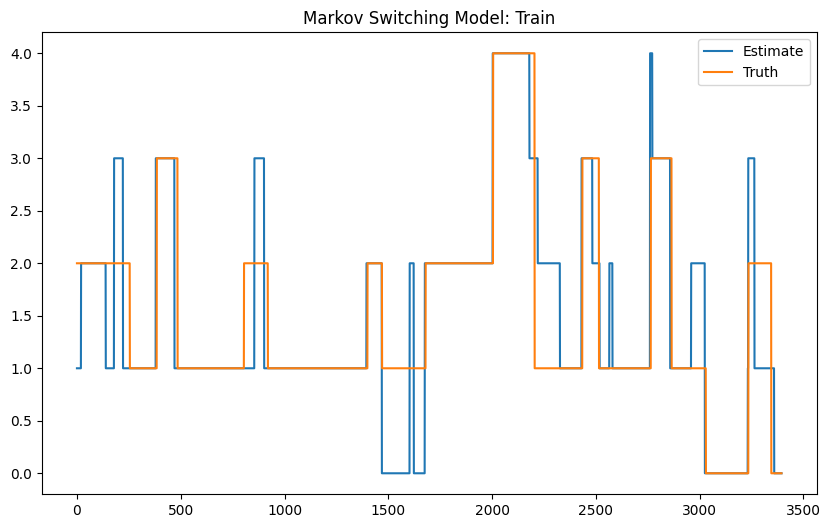

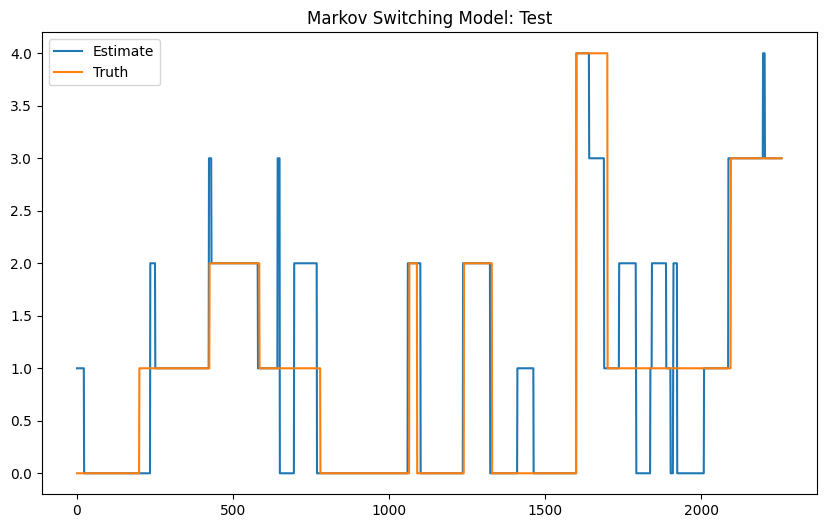

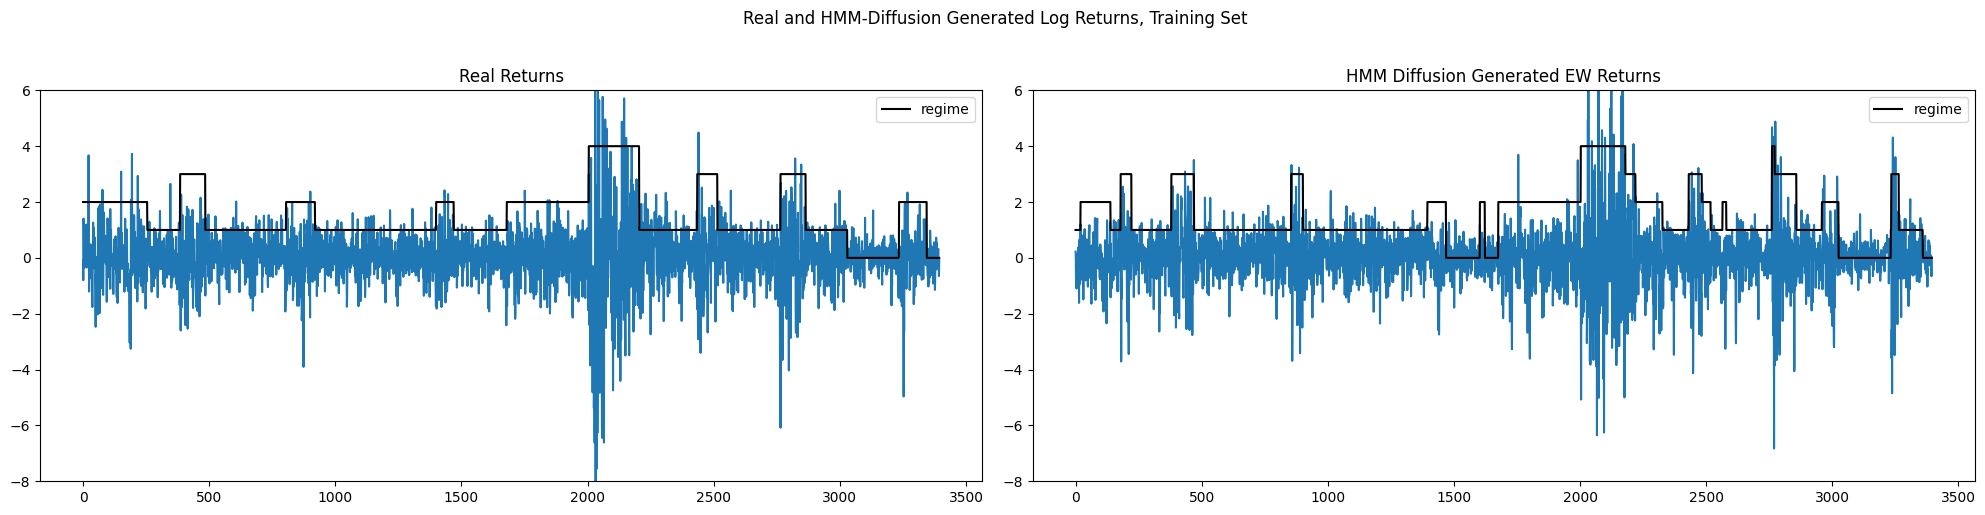

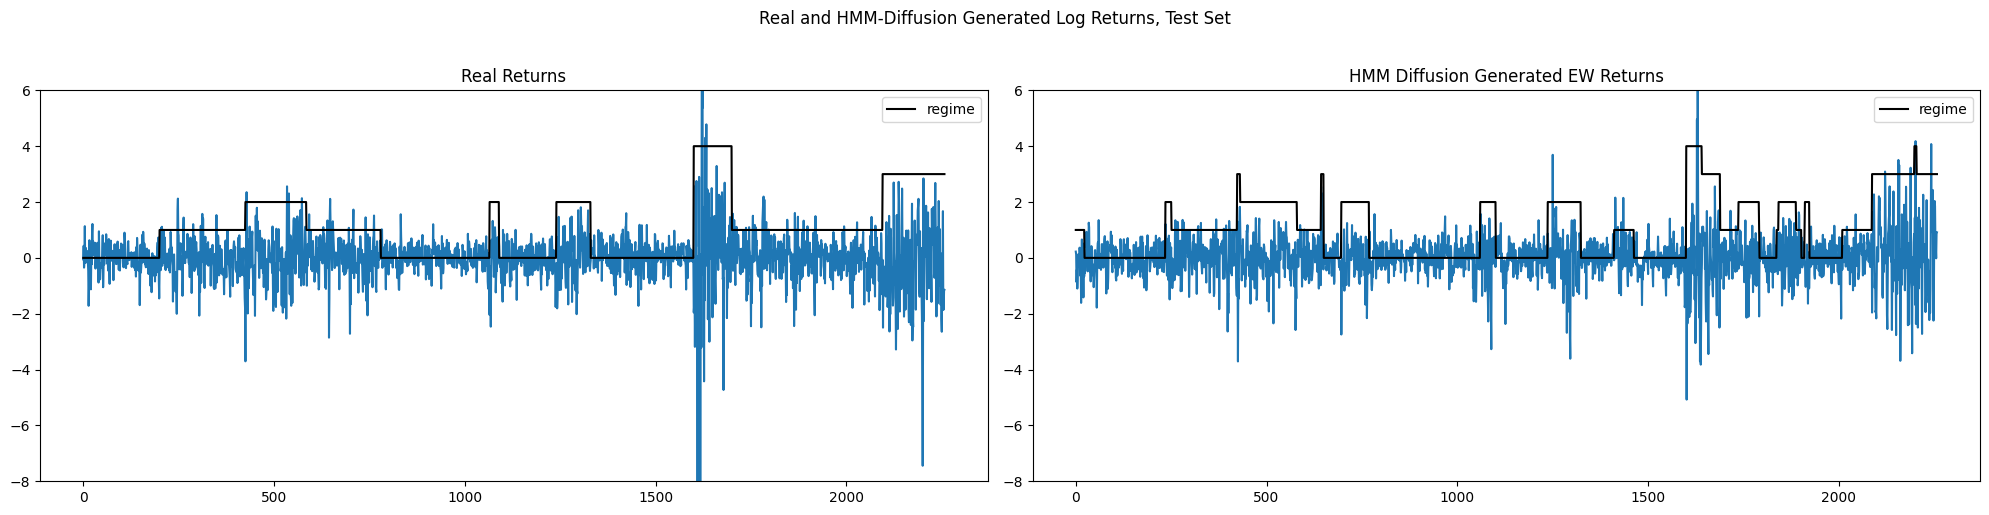

Train backtest


,n,real_mean,gen_mean,real_var,gen_var
regime,,,,,
0,255,0.0106,0.0415,0.2283,0.1821
1,1785,0.0732,0.0447,0.4714,0.5614
2,875,-0.0288,-0.0484,0.8487,0.9518
3,280,-0.0564,-0.0001,1.8587,2.2272
4,200,-0.1225,0.0586,7.2708,5.7796


Test backtest


,n,real_mean,gen_mean,real_var,gen_var
regime,,,,,
0,905,0.0083,0.0081,0.2184,0.2571
1,815,-0.0087,0.0184,0.4747,0.4203
2,275,-0.0308,-0.0995,0.8433,0.8190
3,163,-0.2969,0.0858,2.1447,2.1121
4,100,-0.1150,-0.2810,8.6179,2.5761


In [9]:
results["markov_switching"] = evaluate_variant(
    "markov_switching", models.fit_markov_switching(train_data, N_REGIMES, cfg)
)


[ -0.39671573 -32.936176   -44.438164    -1.7425239   -2.6681895 ]
(1697,)
prev
JitTracer(float32[5])
cur
JitTracer(float32[])
trans
[[-2.603052  -1.7607605 -2.4121323 -2.3816977 -0.5585793]
 [-1.3753742 -0.9098027 -2.8357787 -1.4681387 -2.8891284]
 [-1.9357654 -0.687541  -3.4661908 -3.1763897 -1.2733107]
 [-0.4881314 -1.81827   -2.438177  -2.2725506 -3.394642 ]
 [-2.8772955 -2.5834103 -2.6981206 -0.8134196 -1.0285479]]
loc
[-0.27706242 -1.3087606   1.4700975  -1.1474452   0.5143523 ]
(5,)
[0.28611243 0.16749428 0.1470359  0.8830496  5.7329273 ]
(5,)
(5, 5)
[ -0.39671573 -32.936176   -44.438164    -1.7425239   -2.6681895 ]
log_prob
GradTracer(primal=[ -0.39671573 -32.936176   -44.438164    -1.7425239   -2.6681895 ], typeof(tangent)=f32[5])
(1697,)
prev
JitTracer(float32[5])
cur
JitTracer(float32[])
trans
GradTracer(primal=[[-2.603052  -1.7607605 -2.4121323 -2.3816977 -0.5585793]
 [-1.3753742 -0.9098027 -2.8357787 -1.4681387 -2.8891287]
 [-1.9357654 -0.687541  -3.4661908 -3.1763897 -1.2

  0%|          | 0/300 [00:00<?, ?it/s]

GradTracer(primal=JitTracer(float32[5]), typeof(tangent)=f32[5])
(1697,)
prev
JitTracer(float32[5])
cur
JitTracer(float32[])
trans
GradTracer(primal=JitTracer(float32[5,5]), typeof(tangent)=f32[5,5])
loc
GradTracer(primal=JitTracer(float32[5]), typeof(tangent)=f32[5])
(5,)
GradTracer(primal=JitTracer(float32[5]), typeof(tangent)=f32[5])
(5,)
(5, 5)
GradTracer(primal=JitTracer(float32[5]), typeof(tangent)=f32[5])
log_prob


sample: 100%|██████████| 300/300 [00:06<00:00, 44.81it/s, 5 steps of size 6.45e-02. acc. prob=0.75]  

Semi-Supervised HMM
Posterior transition matrix


to,0,1,2,3,4
from,,,,,
0,0.5510,0.2540,0.1370,0.0500,0.0080
1,0.1370,0.4540,0.2370,0.1030,0.0690
2,0.3110,0.0330,0.1150,0.1760,0.3650
3,0.4270,0.0410,0.3440,0.0430,0.1450
4,0.2070,0.2250,0.1370,0.0990,0.3330


Emission parameters


,mean,sigma
regime,,
0,-1.6315,1.7487
1,0.0407,0.6937
2,1.5848,3.0489
3,-0.5023,0.9130
4,0.7248,1.4502


100%|██████████| 3395/3395 [00:00<00:00, 95963.65it/s]
3395it [00:00, 94671.05it/s]
100%|██████████| 2258/2258 [00:00<00:00, 98426.94it/s]
2258it [00:00, 43766.18it/s]


Train accuracy  49.19%   top-2  60.27%
Test  accuracy  33.53%   top-2  61.25%


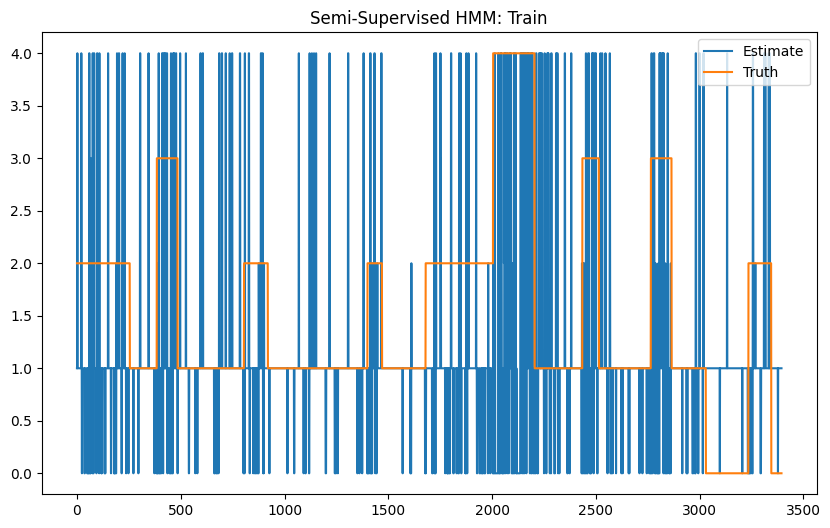

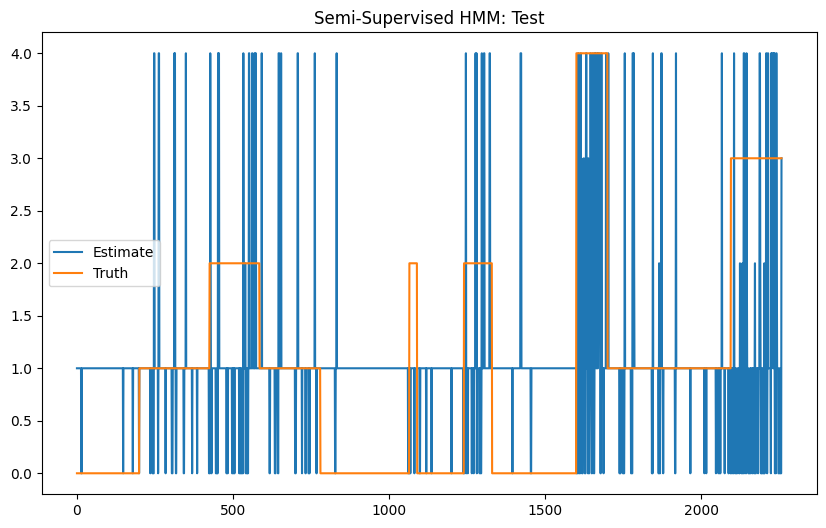

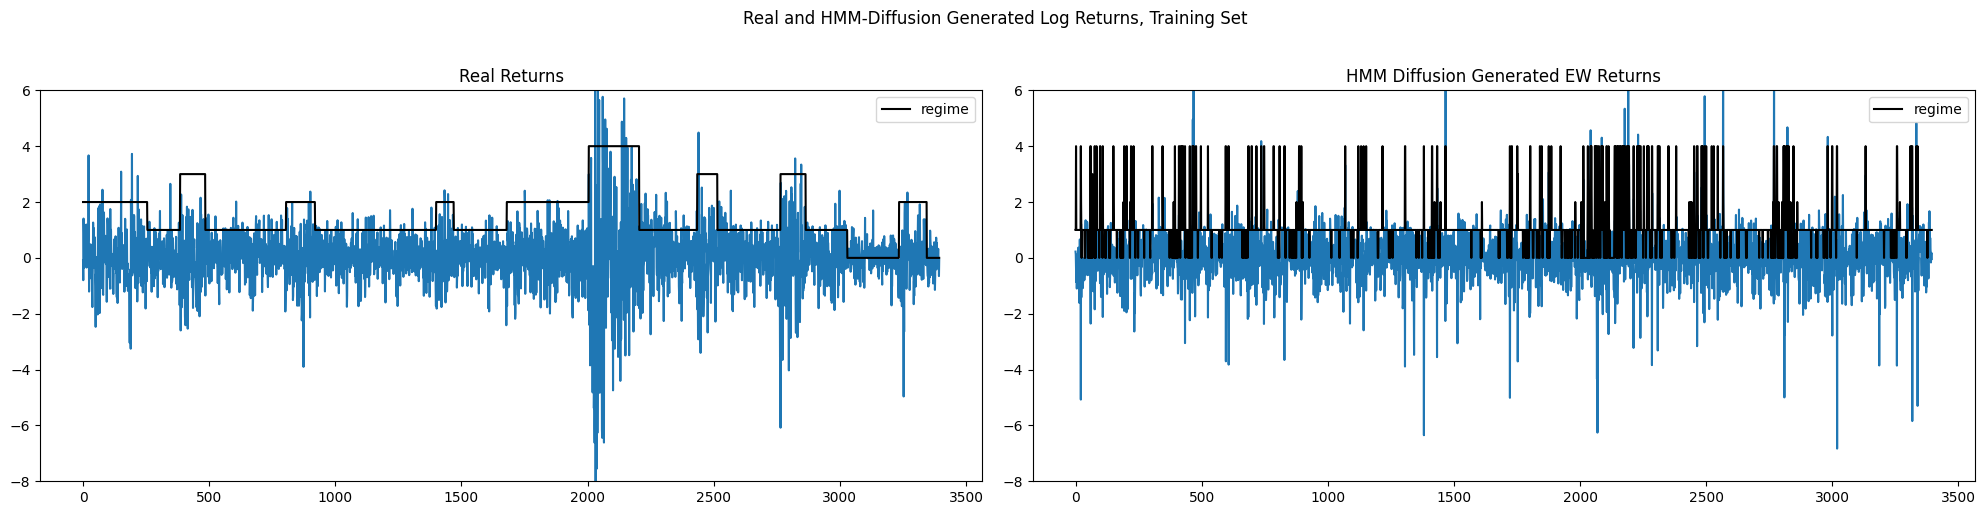

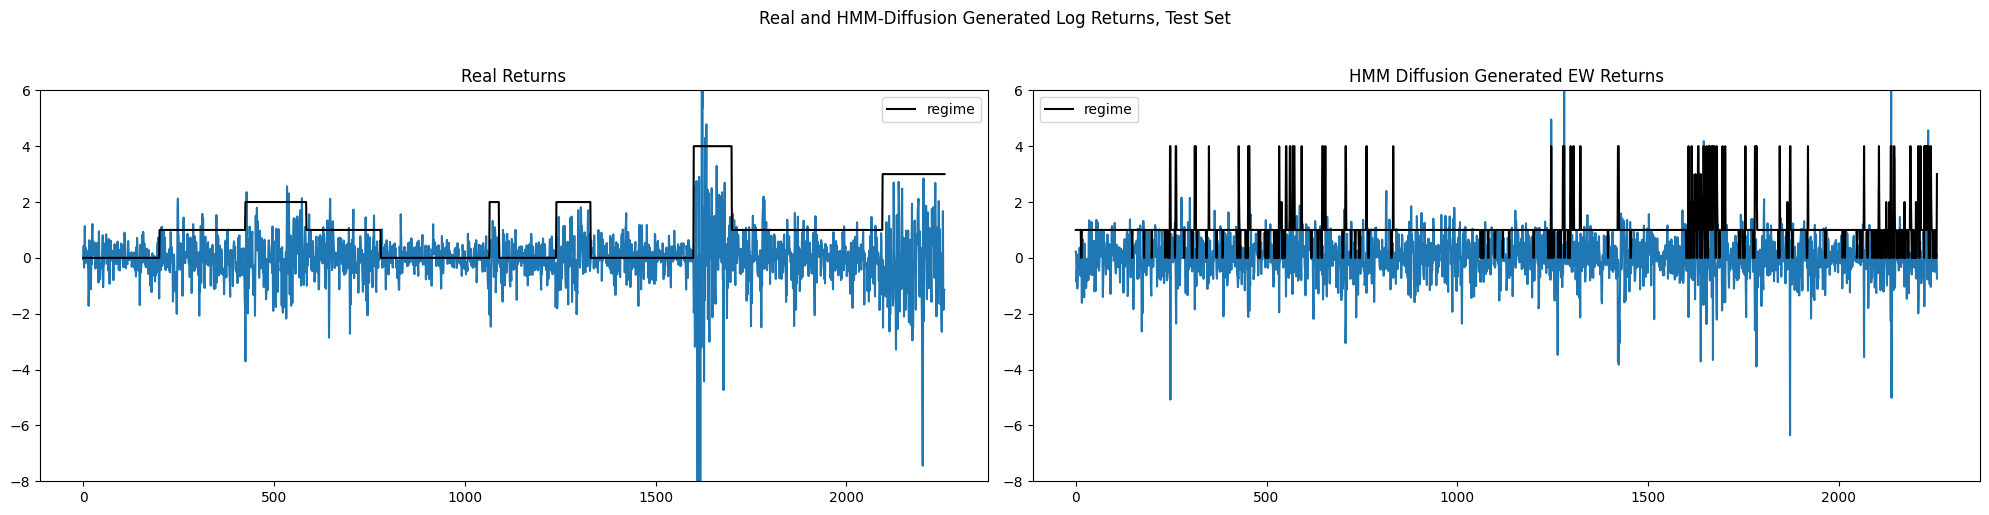

Train backtest


,n,real_mean,gen_mean,real_var,gen_var
regime,,,,,
0,255,0.0106,0.0911,0.2283,0.5657
1,1785,0.0732,0.0506,0.4714,0.6493
2,875,-0.0288,0.0069,0.8487,0.7972
3,280,-0.0564,0.1559,1.8587,1.5578
4,200,-0.1225,0.0459,7.2708,1.6696


Test backtest


,n,real_mean,gen_mean,real_var,gen_var
regime,,,,,
0,905,0.0083,0.0521,0.2184,0.4886
1,815,-0.0087,0.0015,0.4747,0.5789
2,275,-0.0308,0.0295,0.8433,0.6855
3,163,-0.2969,0.0574,2.1447,1.1633
4,100,-0.1150,0.0152,8.6179,1.2913


In [10]:
results["semi_supervised"] = evaluate_variant(
    "semi_supervised", models.fit_semi_supervised_hmm(train_data, N_REGIMES, cfg)
)


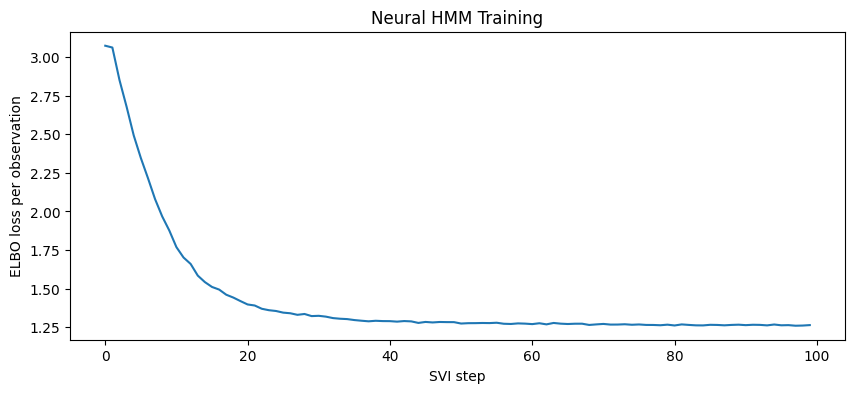

Neural HMM
Posterior transition matrix


to,0,1,2,3,4
from,,,,,
0,0.9920,0.0020,0.0030,0.0020,0.0020
1,0.0020,0.9900,0.0030,0.0030,0.0020
2,0.0030,0.0030,0.9900,0.0020,0.0030
3,0.0020,0.0050,0.0020,0.9900,0.0020
4,0.0010,0.0020,0.0010,0.0010,0.9940


Emission parameters


,mean,sigma
regime,,
0,0.0720,0.6148
1,0.0617,0.6461
2,-0.0004,0.9444
3,-0.0424,1.3497
4,-0.1268,2.0524


100%|██████████| 3395/3395 [00:00<00:00, 101164.86it/s]
3395it [00:00, 103866.36it/s]
100%|██████████| 2258/2258 [00:00<00:00, 101729.79it/s]
2258it [00:00, 102809.83it/s]

Train accuracy  52.61%   top-2  89.72%
Test  accuracy  74.00%   top-2  93.45%


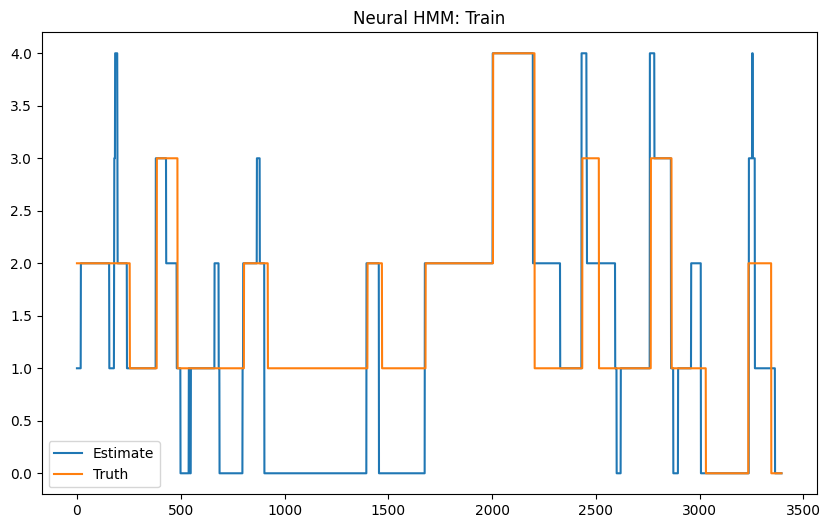

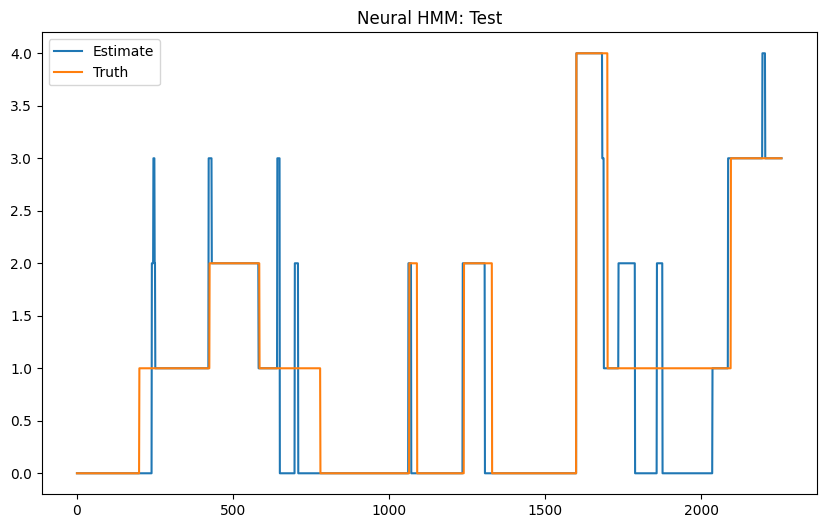

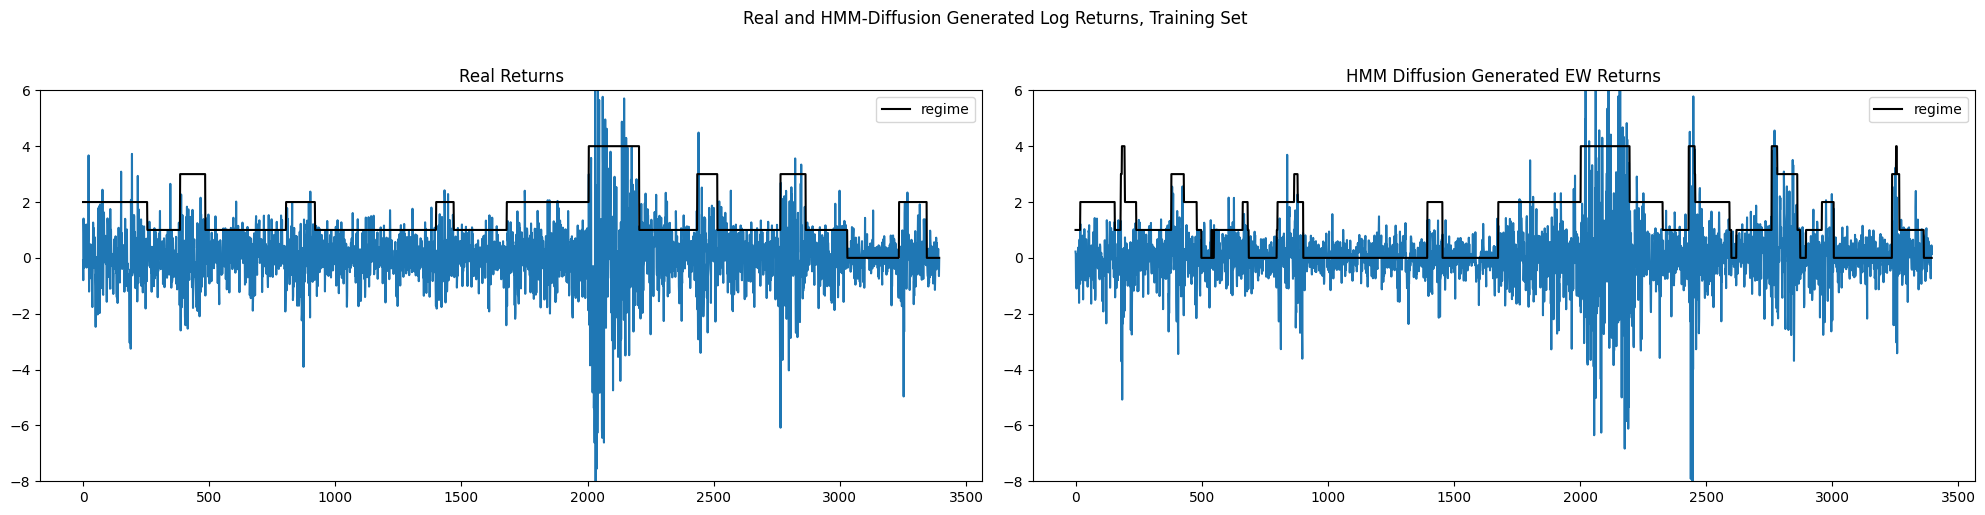

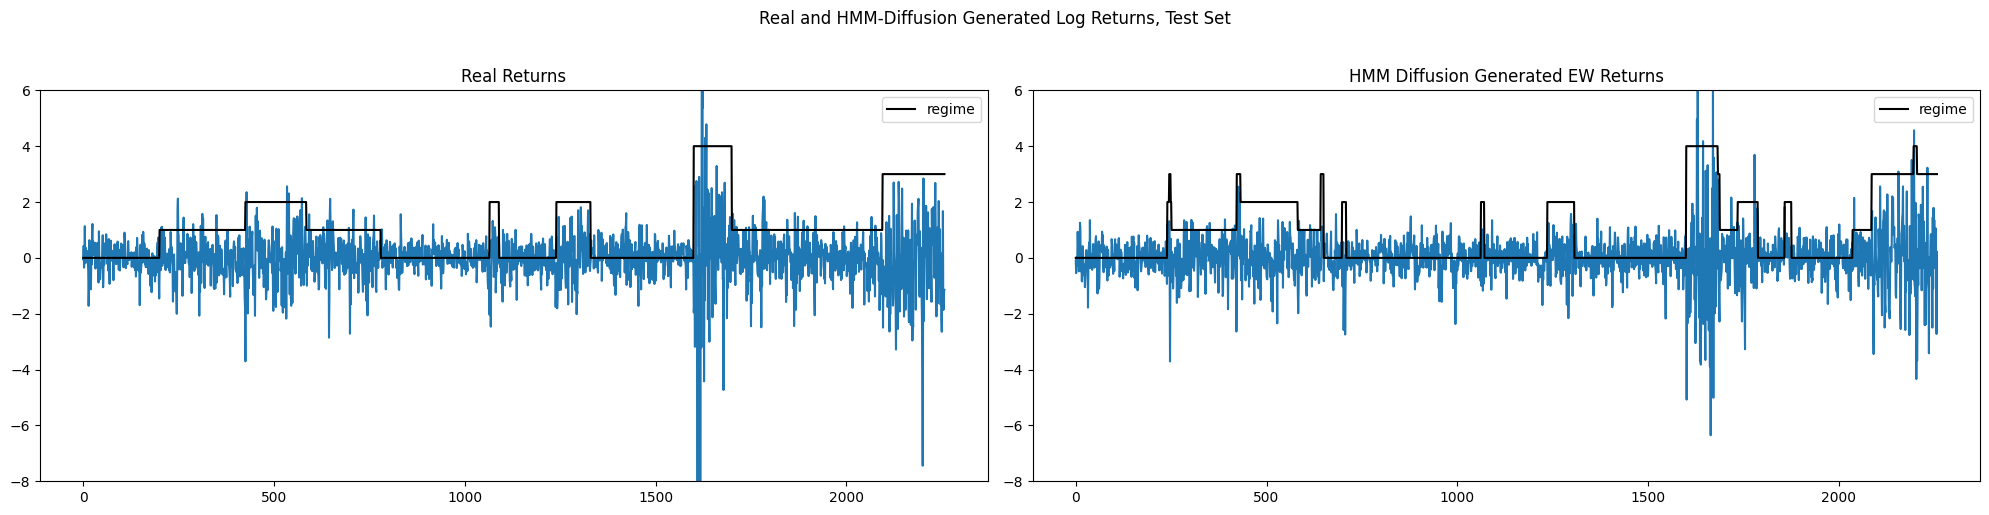

Train backtest


,n,real_mean,gen_mean,real_var,gen_var
regime,,,,,
0,255,0.0106,0.0599,0.2283,0.2252
1,1785,0.0732,0.0267,0.4714,0.4520
2,875,-0.0288,-0.0833,0.8487,0.8496
3,280,-0.0564,-0.0100,1.8587,2.4349
4,200,-0.1225,0.0762,7.2708,7.2591


Test backtest


,n,real_mean,gen_mean,real_var,gen_var
regime,,,,,
0,905,0.0083,0.0008,0.2184,0.2432
1,815,-0.0087,-0.0036,0.4747,0.4342
2,275,-0.0308,0.0056,0.8433,0.5128
3,163,-0.2969,0.0366,2.1447,2.0601
4,100,-0.1150,-0.3774,8.6179,4.6349


In [11]:
neural_fit = models.fit_neural_hmm(train_data, N_REGIMES, cfg)
plots.plot_elbo(neural_fit.diagnostics["elbo_losses"])
results["neural"] = evaluate_variant("neural", neural_fit)


## Results

State-estimation accuracy for all four variants, then the per-regime distributional fit of the generated series. The moment comparison is grouped by the true EW regime while generated values follow the estimated path. The oracle column stitches along the true path to isolate generator quality.


In [12]:
summary = pd.DataFrame(
    [
        {
            "variant": r["name"],
            "train": r["train_accuracy"],
            f"train_top{TOP_K}": r["train_top_k"],
            "test": r["test_accuracy"],
            f"test_top{TOP_K}": r["test_top_k"],
        }
        for key, r in results.items()
    ]
).set_index("variant")

display(summary.style.format("{:.2%}"))


,train,train_top2,test,test_top2
variant,,,,
Supervised HMM,73.58%,90.31%,75.11%,94.29%
Markov Switching Model,73.31%,91.22%,72.32%,95.26%
Semi-Supervised HMM,49.19%,60.27%,33.53%,61.25%
Neural HMM,52.61%,89.72%,74.00%,93.45%


In [13]:
best_key = summary["test"].idxmax()
best = next(r for r in results.values() if r["name"] == best_key)

oracle_table = stitch.backtest_table(
    train_data.emission.values,
    train_data.regime.values,
    best["oracle"],
    train_data.regime.values,
    N_REGIMES,
)

comparison = pd.DataFrame(
    {
        "real_var": oracle_table["real_var"],
        "oracle_var": oracle_table["gen_var"],
        "hmm_var": best["backtest"]["gen_var"],
        "real_mean": oracle_table["real_mean"],
        "oracle_mean": oracle_table["gen_mean"],
        "hmm_mean": best["backtest"]["gen_mean"],
    }
)

print(f"Per-regime moments, stitched with {best_key}")
display(comparison)

if USING_PLACEHOLDER:
    print(
        "\nThese generated columns come from placeholder resampling, not the diffusion specialists."
    )


Per-regime moments, stitched with Supervised HMM


,real_var,oracle_var,hmm_var,real_mean,oracle_mean,hmm_mean
regime,,,,,,
0,0.2283,0.2173,0.2034,0.0106,-0.0158,-0.0085
1,0.4714,0.4522,0.5449,0.0732,0.0560,0.0367
2,0.8487,0.8774,0.8628,-0.0288,-0.0739,-0.0362
3,1.8587,2.1640,2.0749,-0.0564,0.0438,0.0179
4,7.2708,7.2230,6.0106,-0.1225,-0.0034,0.1041
